In [1]:
%reload_ext autoreload
%autoreload 2

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM


In [3]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [65]:
import scipy


train_data = dataset["train"]   

def train_data_generator(batch_size=512):
    key = jax.random.key(0)
    while True:
        key,subkey, subkey2 = jax.random.split(key,3)
        idx = np.random.randint(0,len(train_data), size=batch_size)
        
        xs_batch = train_data[idx]["image"]/256
        #Rotate a bit
        xs_batch = scipy.ndimage.rotate(xs_batch, np.random.uniform()*10, axes=(1,2), reshape=False)
        
        # Quantize
        xs_batch = jnp.array(train_data[idx]["image"]/256, dtype=jnp.float32).reshape(batch_size, 28,28,1)
        xs_batch += jax.random.uniform(subkey2, xs_batch.shape)/255 # Uniform dequantization
        # Rescale to [-1,1]
        xs_batch = 2*xs_batch - 1
        xs_batch = jnp.nan_to_num(xs_batch)
        
    
        
        yield xs_batch

datagenerator = train_data_generator()

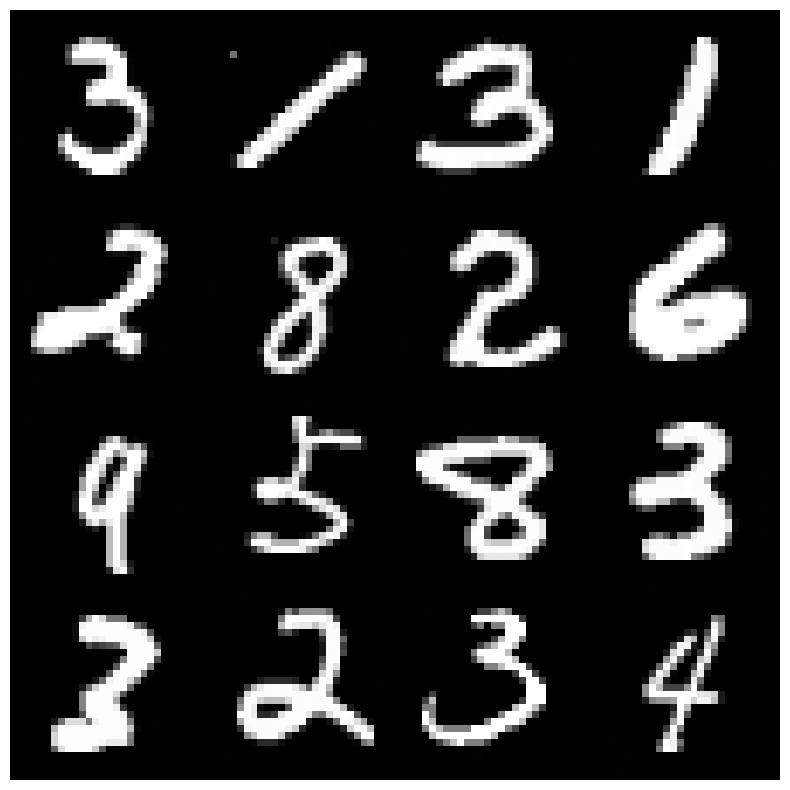

In [7]:
images = [next(datagenerator)[0, ..., 0] for _ in range(16)]
stacked_images = np.vstack([np.hstack(images[i*4:(i+1)*4]) for i in range(4)])

plt.figure(figsize=(10, 10))
plt.imshow(stacked_images, cmap="gray")
plt.axis('off')
plt.show()


In [66]:
from probjax.nn.nets.unets import UNet

In [101]:
d = 784
class Denoiser(nnx.Module):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,128, rngs=rngs, learnable=True)
        self.net = UNet(1, rngs=rngs, kernel_size=(4,4), kernel_size_resnet=(3,3), out_features=[64, 128,256,512, 1024], context_features=128, use_attention=False, use_bias=True, num_groups=8)
        self.out_layer = nnx.Conv(1, 1,1, padding="SAME", kernel_init=nnx.initializers.zeros,use_bias=True, rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        out = self.net(x, context=time_embed)
        out = self.out_layer(out)
        return out

net = Denoiser(d, nnx.Rngs(1))
model = EDM(net, 1.0)
params = nnx.state(model, nnx.Param)

In [102]:
# Count parameters
print("Number of parameters: ", sum(np.prod(v.shape) for v in jax.tree_leaves(params)))

Number of parameters:  129860868


(512, 28, 28, 64)
(512, 14, 14, 128)
(512, 7, 7, 256)
(512, 4, 4, 512)
(512, 2, 2, 1024)


Text(0.5, 1.0, 'Denoised image')

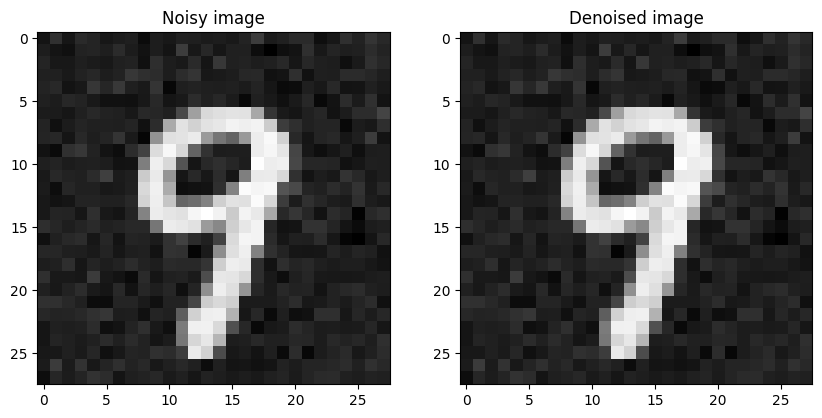

In [103]:
# Visualize initial model denoising
x = next(datagenerator)
t = jnp.ones((x.shape[0],1,1,1)) * 0.1
x = x + jax.random.normal(jax.random.PRNGKey(0), x.shape) * t
y = model(t, x)
# Plot x and y 
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(x[0,...,0], cmap="gray")
ax[0].set_title("Noisy image")
ax[1].imshow(y[0,...,0], cmap="gray")
ax[1].set_title("Denoised image")

In [104]:
def loss_fn(params, x, rng):
    return model.loss(params, rng, x)


In [174]:
from functools import partial
import optax

schedule = optax.cosine_onecycle_schedule(50*200, 5e-4)
opt = optax.chain(optax.adaptive_grad_clip(20.), optax.ema(0.01), optax.adamw(schedule))
params_per_device = jax.tree_util.tree_map(
    lambda p: jnp.stack([p] * jax.local_device_count(), axis=0), 
    params
)
opt_state = jax.vmap(opt.init)(params_per_device)

@partial(jax.pmap, axis_name='batch')
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    grads = jax.tree_map(lambda x: jnp.nan_to_num(x), grads)

    # Average across all replicas on the 'batch' axis
    loss = jax.lax.pmean(loss, axis_name='batch')
    grads = jax.lax.pmean(grads, axis_name='batch')

    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    params = jax.tree_map(lambda x: jnp.nan_to_num(x), params)
    return params, opt_state, loss

def train_step(params, opt_state, xs, rng):
    rngs = jax.random.split(rng, jax.local_device_count())

    # Reshape xs to split across devices
    xs_split = jnp.reshape(xs, (jax.local_device_count(), -1, *xs.shape[1:]))

    params, opt_state, losses = update(params, opt_state, xs_split, rngs)
    return params, opt_state, jnp.mean(losses)


In [175]:
key = jax.random.key(1)

In [176]:
# Example training iteration
for i in range(50):
    l = 0.
    for j in range(200): 
        key, key_data, key_loss = jax.random.split(key, 3)
        xs = next(datagenerator)
        params_per_device, opt_state, loss = train_step(params_per_device, opt_state, xs, key_loss)
        l += loss
    print(l/200)

(512, 1, 1, 1) (512, 28, 28, 1)
(512, 28, 28, 64)
(512, 14, 14, 128)
(512, 7, 7, 256)
(512, 4, 4, 512)
(512, 2, 2, 1024)
59.420288
59.25651
59.460056
59.47912
59.669556
59.890938
60.380554
60.726074
61.05295
61.53373
61.74579
61.92939
62.34592
62.079758
62.335335
62.18351
62.485706
61.863045
62.038807
61.95447
61.852192
61.778397
61.23726
61.127464
60.91592
60.627617
60.359688
60.094597
60.036976
59.51715
59.130424
58.949944
58.267754
58.041218
57.34868
57.093864
56.70918
56.105877
55.90633
55.075497
54.897743
54.382706
54.067375
53.60492
53.513496
53.450775
53.08745
52.973656
52.96028
52.934296


In [177]:
params = jax.tree_map(lambda x: x[0], params_per_device)
nnx.update(model, params)

(512, 28, 28, 64)
(512, 14, 14, 128)
(512, 7, 7, 256)
(512, 4, 4, 512)
(512, 2, 2, 1024)


Text(0.5, 1.0, 'Denoised image')

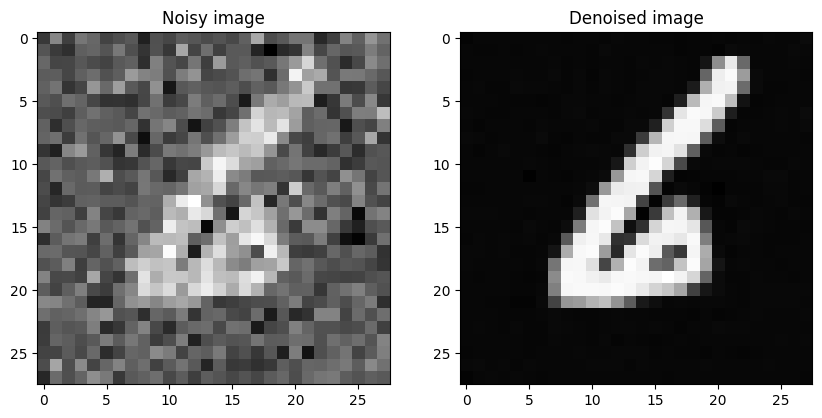

In [178]:
# Visualize initial model denoising
datagenerator = train_data_generator()
x = next(datagenerator)
t = jnp.ones((x.shape[0],1,1,1)) * 0.5
x = x + jax.random.normal(jax.random.PRNGKey(0), x.shape) * t
y = model(t, x)
# Plot x and y 
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(x[0,...,0], cmap="gray")
ax[0].set_title("Noisy image")
ax[1].imshow(y[0,...,0], cmap="gray")
ax[1].set_title("Denoised image")

In [195]:
from probjax.utils.odeint import odeint
from probjax.utils.sdeint import sdeint


def sample(rng, t_min=0.001, t_max=80, rho=5, N = 200):
    rng_init, rng_solve = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (784,)) * t_max
    ts = (t_max**(1/rho) + jnp.linspace(0,1,N) * (t_min**(1/rho) - t_max**(1/rho)))**rho

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((28,28,1))
        f = model.drift(t,x_)
        g = model.diffusion(t, x_)
        score = model.score(t,x_)
        backward_f = (f -g**2*score).reshape(x.shape)
        return backward_f
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((28,28,1))
        g = model.diffusion(t, x_) * jnp.ones_like(x)
        return g.reshape(x.shape)

    return sdeint(rng_solve,drift,diffusion, eps,ts, noise_type="diagonal")[-1]


In [200]:
keys = jax.random.split(jax.random.key(0), (16,))

In [201]:
xs = jax.vmap(sample)(keys)

(28, 28, 64)
(14, 14, 128)
(7, 7, 256)
(4, 4, 512)
(2, 2, 1024)


In [202]:
xs.max(), xs.min()

(Array(1.139, dtype=float32), Array(-1.143, dtype=float32))

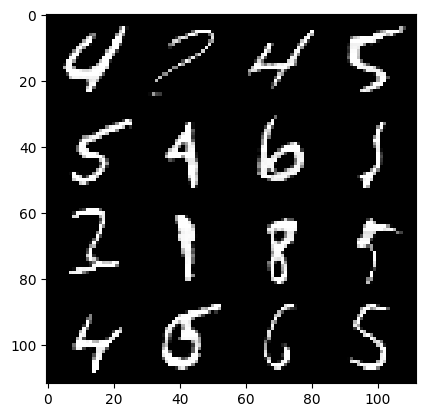

In [203]:
import matplotlib.pyplot as plt

img = xs.reshape(4, 4, 28, 28).transpose(0, 2, 1, 3).reshape(4*28, 4*28)
plt.imshow(img, cmap="gray", vmin=0, vmax=1.)